# Restoring the trained goal proposers

In [2]:
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import jax
import matplotlib.pyplot as plt
import numpy as np

from agents.goal_proposer import make_goal_proposer_config, restore_gc_flow_goal_proposer


/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [3]:
ENV_NAME = 'humanoidmaze-giant-navigate-v0'
ENV_DATASET_PATH = '../../scratch/data/humanoidmaze-giant-navigate-v0/humanoidmaze-giant-navigate-100m-v0/humanoidmaze-giant-navigate-v0-003.npz'

base_config = dict(
    observations_key='observations',
    goal_key='actor_goals',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    flow_steps=10,
    seed=0,
    discount=0.995,
    backup_horizon=25,
)

proposer_specs = {
    'unconditioned_h100': dict(observation_conditioned=False, horizon_conditioned=False),
    'observation_h100': dict(observation_conditioned=True, horizon_conditioned=False),
    'observation_horizon_h1_100': dict(observation_conditioned=True, horizon_conditioned=True),
}

example_batch = dict(
    observations=np.zeros((1, 2), dtype=np.float32),
    actor_goals=np.zeros((1, 2), dtype=np.float32),
    low_actor_goals=np.zeros((1, 2), dtype=np.float32),
    horizons=np.full((1, 1), 100.0, dtype=np.float32),
)


In [4]:
with np.load(ENV_DATASET_PATH) as env_dataset:
    env_xy = env_dataset['observations'][:, :2]
    all_cell_points = np.unique(np.floor(env_xy), axis=0).astype(np.float32)

print(f'{ENV_NAME}: {len(all_cell_points):,} occupied cells')
all_cell_points[:5]


humanoidmaze-giant-navigate-v0: 1,376 occupied cells


array([[-2., -2.],
       [-2., -1.],
       [-2.,  0.],
       [-2.,  1.],
       [-2.,  2.]], dtype=float32)

In [5]:
goal_proposers = {}
checkpoint_steps = {}

for name, spec in proposer_specs.items():
    config = make_goal_proposer_config(name, base_config=base_config, **spec)
    agent, step = restore_gc_flow_goal_proposer(name, example_batch, config)
    goal_proposers[name] = agent
    checkpoint_steps[name] = step
    print(f'{name}: restored checkpoint {step:,}')


Restored from checkpoints/gc_flow_goal_proposer/unconditioned_h100/params_5000000.pkl
unconditioned_h100: restored checkpoint 5,000,000
Restored from checkpoints/gc_flow_goal_proposer/observation_h100/params_5000000.pkl
observation_h100: restored checkpoint 5,000,000
Restored from checkpoints/gc_flow_goal_proposer/observation_horizon_h1_100/params_5000000.pkl
observation_horizon_h1_100: restored checkpoint 5,000,000


In [6]:
conditioning_observation = np.array([0.0, 0.0], dtype=np.float32)
conditioning_horizon = 100.0
num_plot_samples = 128

rng = jax.random.PRNGKey(0)
samples = {}
for name, agent in goal_proposers.items():
    rng, sample_rng = jax.random.split(rng)

    if agent.config['observation_conditioned']:
        observations = np.repeat(conditioning_observation[None], num_plot_samples, axis=0)
    else:
        observations = None

    horizons = None
    if agent.config['horizon_conditioned']:
        horizons = np.full((num_plot_samples, 1), conditioning_horizon, dtype=np.float32)

    if observations is None:
        sample = agent.sample_actions(num_samples=num_plot_samples, horizons=horizons, seed=sample_rng)
    else:
        sample = agent.sample_actions(observations=observations, horizons=horizons, seed=sample_rng)

    samples[name] = np.asarray(sample)

{k: v.shape for k, v in samples.items()}


{'unconditioned_h100': (128, 2),
 'observation_h100': (128, 2),
 'observation_horizon_h1_100': (128, 2)}

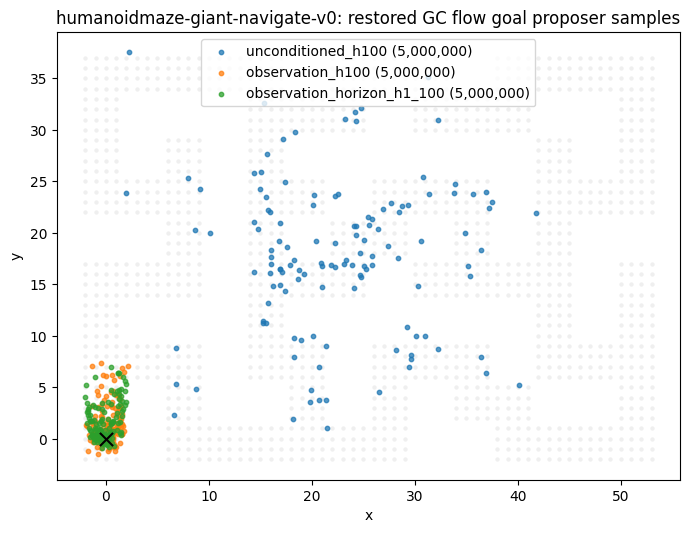

In [7]:
def sample_points(sample):
    points = np.asarray(sample)
    if points.ndim == 1:
        points = points[None, :]
    return points[:, :2]

fig, ax = plt.subplots(figsize=(7, 7))
colors = {
    'unconditioned_h100': 'tab:blue',
    'observation_h100': 'tab:orange',
    'observation_horizon_h1_100': 'tab:green',
}

ax.scatter(
    all_cell_points[:, 0],
    all_cell_points[:, 1],
    s=10,
    alpha=0.12,
    color='gray',
    linewidths=0,
    # label='occupied cells',
)

for name, sample in samples.items():
    points = sample_points(sample)
    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=10,
        alpha=0.75,
        color=colors[name],
        label=f'{name} ({checkpoint_steps[name]:,})',
    )
    label_xy = points[0]
    # ax.annotate(name, xy=label_xy, xytext=(6, 6), textcoords='offset points', fontsize=9)

ax.scatter(
    conditioning_observation[0],
    conditioning_observation[1],
    marker='x',
    s=90,
    color='black',
    # label='conditioning observation',
)
# ax.axhline(0, color='0.85', linewidth=1)
# ax.axvline(0, color='0.85', linewidth=1)
ax.set_title(f'{ENV_NAME}: restored GC flow goal proposer samples')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='best')
fig.tight_layout()


In [8]:
# # Continue each restored proposer for 2M more steps with the same specs/checkpoint cadence as 09.
# # This continues the latest checkpoints, so the current 3,000,000-step agents will save through 5,000,000.
# %run train_restored_goal_proposers.py --additional-steps 2000000 --save-interval 250000


## Classifier-free Guidance

In [60]:
w = 0.6

In [61]:
class CFGGoalProposerAgent:
    def __init__(self, conditioned_agent, unconditioned_agent, w):
        assert conditioned_agent.config['action_dim'] == unconditioned_agent.config['action_dim']
        assert conditioned_agent.config['flow_steps'] == unconditioned_agent.config['flow_steps']
        assert conditioned_agent.config['observation_conditioned']
        assert not unconditioned_agent.config['observation_conditioned']

        self.conditioned_agent = conditioned_agent
        self.unconditioned_agent = unconditioned_agent
        self.w = float(w)

    def sample_actions(self, observations, goals=None, rng=None, seed=None, num_samples=None, override_w=None):
        if rng is None:
            rng = self.conditioned_agent.rng if seed is None else seed

        w = self.w if override_w is None else float(override_w)

        observations = np.asarray(observations, dtype=np.float32)
        single_example = observations.ndim == 1
        if single_example:
            observations = observations[None, :]
            if num_samples is not None:
                observations = np.repeat(observations, int(num_samples), axis=0)
        elif num_samples is not None:
            raise ValueError('num_samples should only be used with a single observation')

        if not self.conditioned_agent.config['goal_conditioned']:
            goals = None

        x = jax.random.normal(rng, (observations.shape[0], self.conditioned_agent.config['action_dim']))
        flow_steps = int(self.conditioned_agent.config['flow_steps'])
        uncond_observations = jnp.zeros((observations.shape[0], 0), dtype=jnp.float32)

        for i in range(flow_steps):
            t = jnp.full((observations.shape[0], 1), i / flow_steps)
            v_cond = self.conditioned_agent.network(observations, goals=goals, actions=x, times=t)
            v_uncond = self.unconditioned_agent.network(uncond_observations, goals=None, actions=x, times=t)
            x = x + (v_uncond + w * (v_cond - v_uncond)) / flow_steps

        return x[0] if single_example and num_samples is None else x


In [62]:
cfg = CFGGoalProposerAgent(unconditioned_agent=goal_proposers['unconditioned_h100'], conditioned_agent=goal_proposers['observation_h100'], w=w)

In [63]:
conditioning_observation = np.array([0.0, 0.0], dtype=np.float32)

import jax.numpy as jnp
rng = jax.random.PRNGKey(0)

sample_rng, rng = jax.random.split(rng)
subgoals = cfg.sample_actions(observations=conditioning_observation, num_samples=128, rng=sample_rng)

In [64]:
all_cell_points_list = [(int(s[0]), int(s[1])) for s in all_cell_points]
print(all_cell_points_list)

[(-2, -2), (-2, -1), (-2, 0), (-2, 1), (-2, 2), (-2, 3), (-2, 4), (-2, 5), (-2, 6), (-2, 7), (-2, 8), (-2, 9), (-2, 10), (-2, 11), (-2, 12), (-2, 13), (-2, 14), (-2, 15), (-2, 16), (-2, 17), (-2, 22), (-2, 23), (-2, 24), (-2, 25), (-2, 26), (-2, 27), (-2, 28), (-2, 29), (-2, 30), (-2, 31), (-2, 32), (-2, 33), (-2, 34), (-2, 35), (-2, 36), (-2, 37), (-1, -2), (-1, -1), (-1, 0), (-1, 1), (-1, 2), (-1, 3), (-1, 4), (-1, 5), (-1, 6), (-1, 7), (-1, 8), (-1, 9), (-1, 10), (-1, 11), (-1, 12), (-1, 13), (-1, 14), (-1, 15), (-1, 16), (-1, 17), (-1, 22), (-1, 23), (-1, 24), (-1, 25), (-1, 26), (-1, 27), (-1, 28), (-1, 29), (-1, 30), (-1, 31), (-1, 32), (-1, 33), (-1, 34), (-1, 35), (-1, 36), (-1, 37), (0, -2), (0, -1), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 28), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0,

In [65]:
invalid_count = np.zeros(len(subgoals))
for i in range(len(subgoals)):
    rounded = np.round(subgoals[i])
    rounded = (int(rounded[0]), int(rounded[1]))
    # print(rounded)
    if rounded not in all_cell_points_list:
        invalid_count[i] = 1.0

fraction_invalid = invalid_count.sum() / invalid_count.shape[0]
print(fraction_invalid)

0.328125


In [66]:
[-5.0, -5.0] in all_cell_points

False

In [67]:
all_cell_points[0]

array([-2., -2.], dtype=float32)

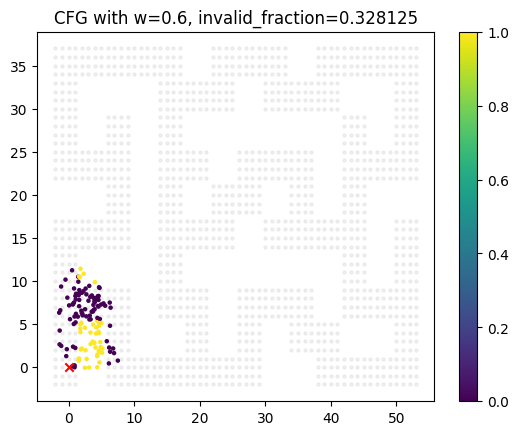

In [68]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=5, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=5, c=invalid_count, cmap='viridis')
plt.scatter(x=conditioning_observation[0], y=conditioning_observation[1], marker='x', color='red')
plt.title(f'CFG with w={w}, invalid_fraction={fraction_invalid}')
plt.colorbar()
plt.show()

## Comparing the invalid fractions

0.1328125


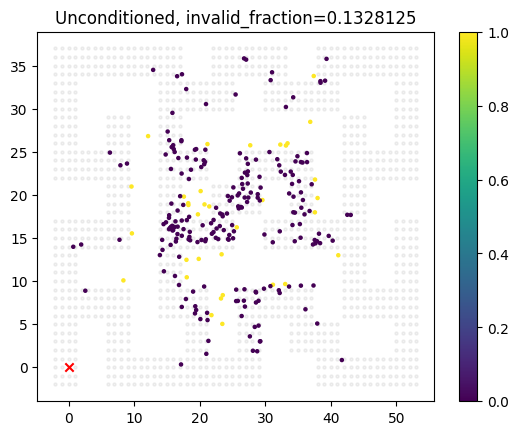

In [19]:
sample_rng, rng = jax.random.split(rng)
subgoals = goal_proposers['unconditioned_h100'].sample_actions(observations=conditioning_observation, num_samples=256, rng=sample_rng)

invalid_count = np.zeros(len(subgoals))
for i in range(len(subgoals)):
    rounded = np.round(subgoals[i])
    rounded = (int(rounded[0]), int(rounded[1]))
    if rounded not in all_cell_points_list:
        invalid_count[i] = 1.0

fraction_invalid = invalid_count.sum() / invalid_count.shape[0]
print(fraction_invalid)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=5, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=5, c=invalid_count, cmap='viridis')
plt.scatter(x=conditioning_observation[0], y=conditioning_observation[1], marker='x', color='red')
plt.title(f'Unconditioned, invalid_fraction={fraction_invalid}')
plt.colorbar()
plt.show()

0.06640625


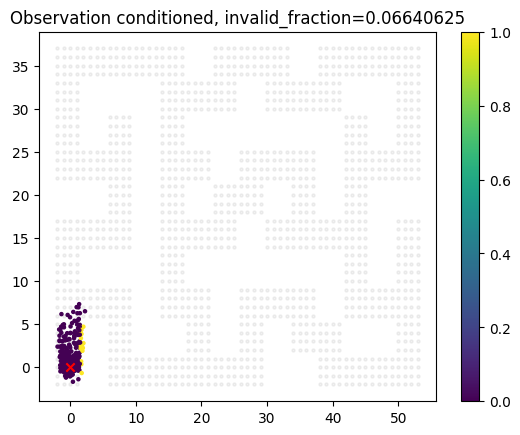

In [20]:
sample_rng, rng = jax.random.split(rng)
subgoals = goal_proposers['observation_h100'].sample_actions(observations=np.repeat(conditioning_observation[None], 256, axis=0), num_samples=256, rng=sample_rng)

invalid_count = np.zeros(len(subgoals))
for i in range(len(subgoals)):
    rounded = np.round(subgoals[i])
    rounded = (int(rounded[0]), int(rounded[1]))
    if rounded not in all_cell_points_list:
        invalid_count[i] = 1.0

fraction_invalid = invalid_count.sum() / invalid_count.shape[0]
print(fraction_invalid)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=5, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=5, c=invalid_count, cmap='viridis')
plt.scatter(x=conditioning_observation[0], y=conditioning_observation[1], marker='x', color='red')
plt.title(f'Observation conditioned, invalid_fraction={fraction_invalid}')
plt.colorbar()
plt.show()

In [23]:


conditioning_observation = np.asarray([31.0, 15.0])

0.11328125


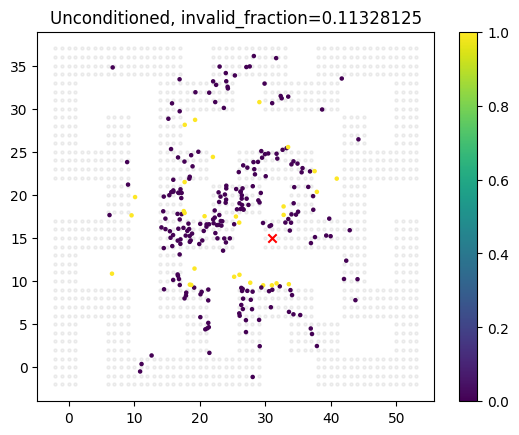

In [24]:
sample_rng, rng = jax.random.split(rng)
subgoals = goal_proposers['unconditioned_h100'].sample_actions(observations=conditioning_observation, num_samples=256, rng=sample_rng)

invalid_count = np.zeros(len(subgoals))
for i in range(len(subgoals)):
    rounded = np.round(subgoals[i])
    rounded = (int(rounded[0]), int(rounded[1]))
    if rounded not in all_cell_points_list:
        invalid_count[i] = 1.0

fraction_invalid = invalid_count.sum() / invalid_count.shape[0]
print(fraction_invalid)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=5, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=5, c=invalid_count, cmap='viridis')
plt.scatter(x=conditioning_observation[0], y=conditioning_observation[1], marker='x', color='red')
plt.title(f'Unconditioned, invalid_fraction={fraction_invalid}')
plt.colorbar()
plt.show()

0.02734375


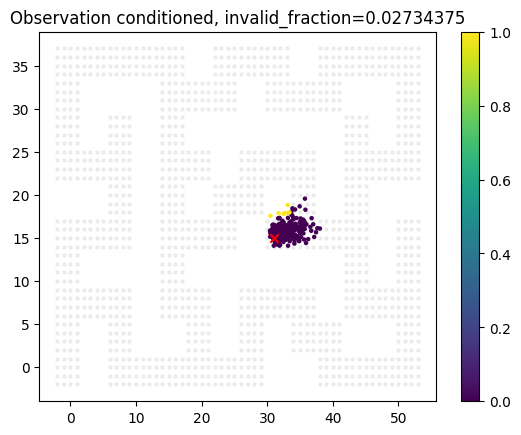

In [25]:
sample_rng, rng = jax.random.split(rng)
subgoals = goal_proposers['observation_h100'].sample_actions(observations=np.repeat(conditioning_observation[None], 256, axis=0), num_samples=256, rng=sample_rng)

invalid_count = np.zeros(len(subgoals))
for i in range(len(subgoals)):
    rounded = np.round(subgoals[i])
    rounded = (int(rounded[0]), int(rounded[1]))
    if rounded not in all_cell_points_list:
        invalid_count[i] = 1.0

fraction_invalid = invalid_count.sum() / invalid_count.shape[0]
print(fraction_invalid)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=5, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=5, c=invalid_count, cmap='viridis')
plt.scatter(x=conditioning_observation[0], y=conditioning_observation[1], marker='x', color='red')
plt.title(f'Observation conditioned, invalid_fraction={fraction_invalid}')
plt.colorbar()
plt.show()

0.4140625


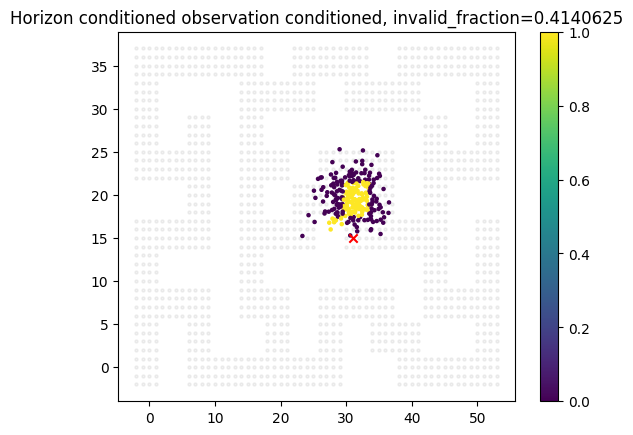

In [31]:
sample_rng, rng = jax.random.split(rng)
subgoals = goal_proposers['observation_horizon_h1_100'].sample_actions(observations=np.repeat(conditioning_observation[None], 256, axis=0), horizons=np.repeat(np.asarray([1000.0]), 256, axis=0), num_samples=256, rng=sample_rng)

invalid_count = np.zeros(len(subgoals))
for i in range(len(subgoals)):
    rounded = np.round(subgoals[i])
    rounded = (int(rounded[0]), int(rounded[1]))
    if rounded not in all_cell_points_list:
        invalid_count[i] = 1.0

fraction_invalid = invalid_count.sum() / invalid_count.shape[0]
print(fraction_invalid)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=5, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=5, c=invalid_count, cmap='viridis')
plt.scatter(x=conditioning_observation[0], y=conditioning_observation[1], marker='x', color='red')
plt.title(f'Horizon conditioned observation conditioned, invalid_fraction={fraction_invalid}')
plt.colorbar()
plt.show()

0.46484375


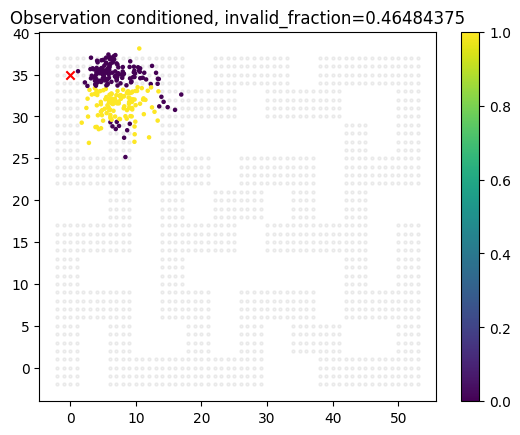

In [40]:
sample_rng, rng = jax.random.split(rng)

conditioning_observation = np.asarray([0.0, 35.0])
subgoals = goal_proposers['observation_horizon_h1_100'].sample_actions(observations=np.repeat(conditioning_observation[None], 256, axis=0), horizons=np.repeat(np.asarray([400.0]), 256, axis=0), num_samples=256, rng=sample_rng)

invalid_count = np.zeros(len(subgoals))
for i in range(len(subgoals)):
    rounded = np.round(subgoals[i])
    rounded = (int(rounded[0]), int(rounded[1]))
    if rounded not in all_cell_points_list:
        invalid_count[i] = 1.0

fraction_invalid = invalid_count.sum() / invalid_count.shape[0]
print(fraction_invalid)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=5, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=5, c=invalid_count, cmap='viridis')
plt.scatter(x=conditioning_observation[0], y=conditioning_observation[1], marker='x', color='red')
plt.title(f'Observation conditioned, invalid_fraction={fraction_invalid}')
plt.colorbar()
plt.show()

## Exploring with the agent

In [69]:
PATH = '../../scratch/dqc-reproduce/sd100001s_33415523.0.33415522.1.20260415_020458/'

CKPT_NUM = 1000000

In [70]:
import json
import os

import numpy as np

from agents import agents
from utils.datasets import Dataset, GCDataset, HGCDataset, CGCDataset
from utils.flax_utils import restore_agent

In [71]:
flags_path = os.path.join(PATH, 'flags.json')
with open(flags_path, 'r') as f:
    saved_flags = json.load(f)

agent_config = saved_flags['agent']
dataset_class_name = agent_config.get('dataset_class', 'GCDataset')
dataset_class = {
    'GCDataset': GCDataset,
    'HGCDataset': HGCDataset,
    'CGCDataset': CGCDataset,
}[dataset_class_name]

# dataset_path = os.path.join(PATH, 'data-100000.npz')
# dataset_npz = np.load('../../scratch/data/humanoidmaze-giant-navigate-v0/humanoidmaze-giant-navigate-100m-v0/humanoidmaze-giant-navigate-v0-003.npz')
# train_dataset = dataset_class(Dataset.create(**dict(dataset_npz)), config=agent_config)

seed = saved_flags.get('seed', 0)


In [73]:
from wrappers.datafuncs_utils import make_env_and_datasets

env, base_train_dataset, val_dataset = make_env_and_datasets(
    'humanoidmaze-giant-navigate-v0',
    dataset_path='../../scratch/data/humanoidmaze-giant-navigate-v0/humanoidmaze-giant-navigate-100m-v0/humanoidmaze-giant-navigate-v0-003.npz',
    use_oracle_reps=True,
)
train_dataset = CGCDataset(base_train_dataset, config=config)

In [74]:
agent_config['train_goal_proposer'] = False
example_batch = train_dataset.sample(1)

first_agent = agents[agent_config['agent_name']].create(seed, example_batch, agent_config)
first_agent = restore_agent(first_agent, PATH, CKPT_NUM)

print(f'Restored first_agent from checkpoint {CKPT_NUM}')
dqc_agent = first_agent

Restored from ../../scratch/dqc-reproduce/sd100001s_33415523.0.33415522.1.20260415_020458//params_1000000.pkl
Restored first_agent from checkpoint 1000000


In [81]:
def sigmoid(x):
    x = np.asarray(x)
    return np.where(
        x >= 0,
        1 / (1 + np.exp(-x)),
        np.exp(x) / (1 + np.exp(x)),
    )

def value_xy(ob, subgoals, goal, agent=dqc_agent):
    assert subgoals.ndim > 1, 'did not provide multiple subgoals'
    subgoal_obs = np.repeat(ob[None], len(subgoals), axis=0)
    subgoal_obs[..., :2] = subgoals
    goals = np.repeat(goal[None], len(subgoals), axis=0)

    vs = agent.network.select('value')(subgoal_obs, goals)
    return vs

def dynamical_distance(ob, subgoals, goal, agent=dqc_agent):

    all_obs = np.repeat(ob[None], len(subgoals), axis=0)
    ob_to_subgoal_vs = agent.network.select('value')(all_obs, subgoals)
    subgoal_to_goal_vs = value_xy(ob, subgoals, goal)
    ob_to_goal_v = agent.network.select('value')(ob, goal)

    ob_to_subgoal_vs = sigmoid(ob_to_subgoal_vs)
    subgoal_to_goal_vs = sigmoid(subgoal_to_goal_vs)
    ob_to_goal_v = sigmoid(ob_to_goal_v)

    gamma_to_subgoal = np.log(np.clip(ob_to_subgoal_vs, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])
    gamma_to_goal = np.log(np.clip(subgoal_to_goal_vs, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])
    ob_to_goal = np.log(np.clip(ob_to_goal_v, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])

    return gamma_to_subgoal, gamma_to_goal, ob_to_goal

In [82]:
from tqdm import tqdm

In [122]:
# ob, _ = env.reset(options=dict(task_id=cur_task_id))
goal = np.asarray([0.0, 34.0])
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(np.asarray([50.0, 0.0])),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

start = ob.copy()[:2]

subgoal = None
to_subgoal = 0
replay_buffer = []
subgoals_buffer = []

steps_to_subgoal = 25
num_subgoals=64

args = dict(
    mult_factor=0.999,
    additive_factor=0.0,
    A_B_factor=0.2,
    B_C_factor=1.0,
    num_trial_steps=4000
)

for s in tqdm(range(args['num_trial_steps'])):
    replay_buffer.append(ob)

    if subgoal is None or to_subgoal == steps_to_subgoal:
        rng, sample_rng = jax.random.split(rng)
        # subgoals = np.asarray(sample_n(ob, goal, num_subgoals, sample_rng))
        subgoals = goal_proposers['observation_h100'].sample_actions(observations=np.repeat(ob[:2][None], num_subgoals, axis=0), num_samples=num_subgoals, rng=sample_rng)

        gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
        gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
        gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
        ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

        mask = gamma_to_goal < ob_to_goal * args['mult_factor'] + args['additive_factor']
        if not np.any(mask):
            print(f'no improving subgoal found at step {s}')
            break

        filtered_subgoals = subgoals[mask]
        filtered_scores = (args['A_B_factor'] * gamma_to_subgoal + args['B_C_factor'] * gamma_to_goal)[mask]
        subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]
        subgoals_buffer.append(subgoal)
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng, best_of_n_override=2)
    to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.1:
        subgoal = None
    
    if terminated or np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        success = 1.0
        break

  0%|          | 0/4000 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [01:14<00:00, 53.36it/s]


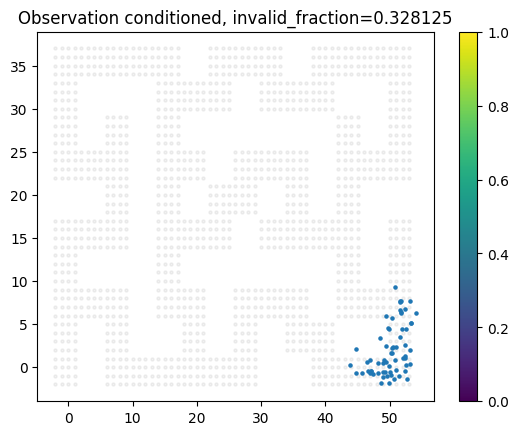

In [121]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=5, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=5)
plt.title(f'Observation conditioned, invalid_fraction={fraction_invalid}')
plt.colorbar()
plt.show()

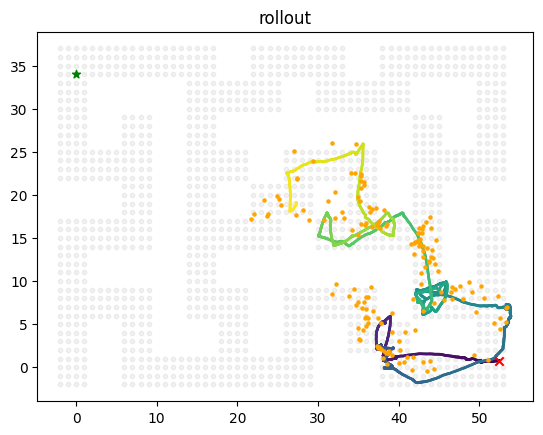

In [124]:
replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=5)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('rollout')
plt.show()

In [107]:
# ob, _ = env.reset(options=dict(task_id=cur_task_id))
goal = np.asarray([0.0, 34.0])
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(np.asarray([50.0, 0.0])),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

start = ob.copy()[:2]

subgoal = None
to_subgoal = 0
replay_buffer = []
subgoals_buffer = []

steps_to_subgoal = 25
num_subgoals=128

args = dict(
    mult_factor=1.0,
    additive_factor=0.0,
    A_B_factor=1.0,
    B_C_factor=1.0,
    num_trial_steps=4000
)

for s in tqdm(range(args['num_trial_steps'])):
    replay_buffer.append(ob)

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng, best_of_n_override=2)
    # to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    # if np.linalg.norm(ob[:2] - subgoal) < 0.1:
    #     subgoal = None
    
    if terminated or np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        success = 1.0
        break

  0%|          | 0/4000 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [00:57<00:00, 69.89it/s]


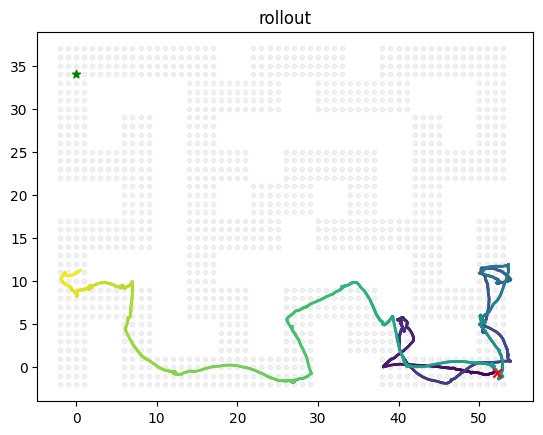

In [108]:
replay_buffer = np.asarray(replay_buffer)
# subgoals_buffer = np.asarray(subgoals_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
# plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=5)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('rollout')
plt.show()